In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv(r"D:\Data Analytics & Data Science\NetMax Technologies\Instagram_visits_clustering.csv")
df.head()

,User ID,Instagram visit score,Spending_rank(0 to 100)
0,0,63,24.050708
1,1,61,25.223290
2,2,104,18.528245
3,3,82,86.890232
4,4,14,31.492397


In [3]:
# renaming the columns for better understanding
df.rename(columns={'Instagram visit score': 'Instagram_Visits', 'Spending_rank(0 to 100)': 'Spending_rank'}, inplace=True)

In [4]:
df.head()

,User ID,Instagram_Visits,Spending_rank
0,0,63,24.050708
1,1,61,25.223290
2,2,104,18.528245
3,3,82,86.890232
4,4,14,31.492397


In [5]:
# changing spending rank to integer type
df['Spending_rank'] = df['Spending_rank'].astype(int)

In [6]:
df.head()

,User ID,Instagram_Visits,Spending_rank
0,0,63,24
1,1,61,25
2,2,104,18
3,3,82,86
4,4,14,31


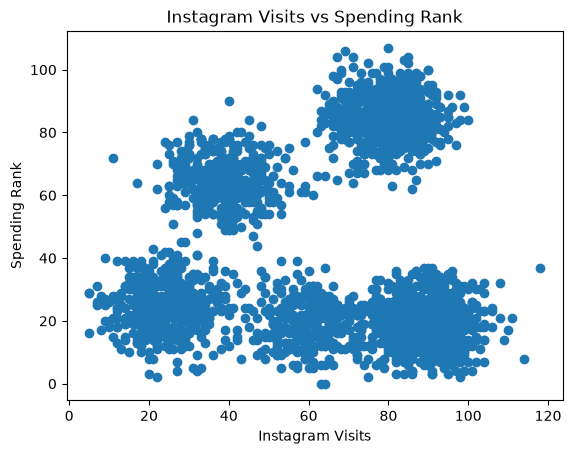

In [8]:
# plotting the data to visualize the clusters
plt.scatter(df['Instagram_Visits'], df['Spending_rank'])
plt.xlabel('Instagram Visits')
plt.ylabel('Spending Rank')
plt.title('Instagram Visits vs Spending Rank')
plt.show()

In [15]:
# feature selection
x = df[['Instagram_Visits', 'Spending_rank']]

model = KMeans(n_clusters=5, random_state=42)

model.fit(x)

,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [16]:
# cluster labels
clusters = model.labels_
clusters

array([0, 0, 4, ..., 2, 4, 1], shape=(2600,), dtype=int32)

In [17]:
# adding cluster labels to the original dataframe
df['Cluster'] = clusters

In [18]:
df.head()

,User ID,Instagram_Visits,Spending_rank,Cluster
0,0,63,24,0
1,1,61,25,0
2,2,104,18,4
3,3,82,86,2
4,4,14,31,3


In [19]:
# centroids of the clusters
centroids = model.cluster_centers_
centroids

array([[60.00643087, 19.23794212],
       [39.27135678, 64.74874372],
       [79.615     , 84.52      ],
       [23.954     , 24.486     ],
       [89.25790139, 19.44121365]])

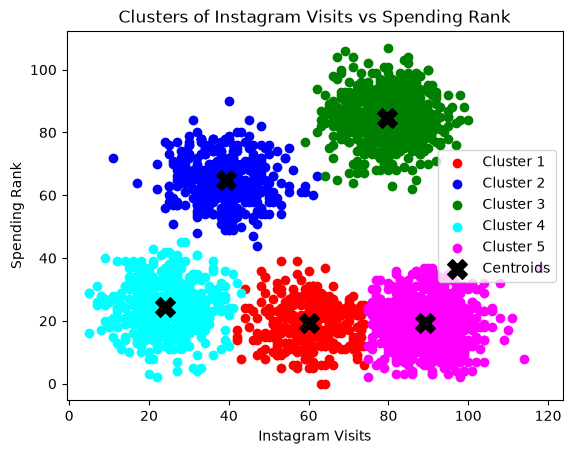

In [21]:
# plotting different clusters with different colors
plt.scatter(df[df['Cluster'] == 0]['Instagram_Visits'], df[df['Cluster'] == 0]['Spending_rank'], color='red', label='Cluster 1')
plt.scatter(df[df['Cluster'] == 1]['Instagram_Visits'], df[df['Cluster'] == 1]['Spending_rank'], color='blue', label='Cluster 2')
plt.scatter(df[df['Cluster'] == 2]['Instagram_Visits'], df[df['Cluster'] == 2]['Spending_rank'], color='green', label='Cluster 3')
plt.scatter(df[df['Cluster'] == 3]['Instagram_Visits'], df[df['Cluster'] == 3]['Spending_rank'], color='cyan', label='Cluster 4')
plt.scatter(df[df['Cluster'] == 4]['Instagram_Visits'], df[df['Cluster'] == 4]['Spending_rank'], color='magenta', label='Cluster 5')
plt.scatter(centroids[:, 0], centroids[:, 1], color='black', marker='X', s=200, label='Centroids')
plt.xlabel('Instagram Visits')
plt.ylabel('Spending Rank')
plt.title('Clusters of Instagram Visits vs Spending Rank')
plt.legend()
plt.show()

In [22]:
# silhouette score to evaluate the clustering
silhouette_avg = silhouette_score(x, clusters)
print(f'Silhouette Score: {silhouette_avg}')

Silhouette Score: 0.6200650327517334


In [23]:
# scaling the data for better clustering
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [25]:
model.fit(x_scaled)

,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [26]:
labels_scaled = model.labels_
labels_scaled

array([4, 4, 0, ..., 2, 0, 1], shape=(2600,), dtype=int32)

In [27]:
df["Cluster_Scaled"] = labels_scaled
df.head()

,User ID,Instagram_Visits,Spending_rank,Cluster,Cluster_Scaled
0,0,63,24,0,4
1,1,61,25,0,4
2,2,104,18,4,0
3,3,82,86,2,2
4,4,14,31,3,3


In [28]:
centroids_scaled = model.cluster_centers_
centroids_scaled

array([[ 0.97590907, -0.79639186],
       [-0.90507708,  0.77929584],
       [ 0.61304814,  1.46689292],
       [-1.48290318, -0.62126084],
       [-0.12687048, -0.80237301]])

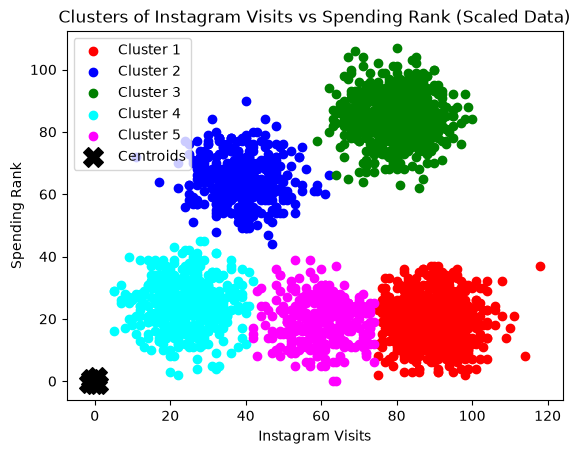

In [29]:
# plotting the data to visualize the clusters with scaled data
plt.scatter(df[df['Cluster_Scaled'] == 0]['Instagram_Visits'], df[df['Cluster_Scaled'] == 0]['Spending_rank'], color='red', label='Cluster 1')
plt.scatter(df[df['Cluster_Scaled'] == 1]['Instagram_Visits'], df[df['Cluster_Scaled'] == 1]['Spending_rank'], color='blue', label='Cluster 2')
plt.scatter(df[df['Cluster_Scaled'] == 2]['Instagram_Visits'], df[df['Cluster_Scaled'] == 2]['Spending_rank'], color='green', label='Cluster 3')
plt.scatter(df[df['Cluster_Scaled'] == 3]['Instagram_Visits'], df[df['Cluster_Scaled'] == 3]['Spending_rank'], color='cyan', label='Cluster 4')
plt.scatter(df[df['Cluster_Scaled'] == 4]['Instagram_Visits'], df[df['Cluster_Scaled'] == 4]['Spending_rank'], color='magenta', label='Cluster 5')
plt.scatter(centroids_scaled[:, 0], centroids_scaled[:, 1], color='black', marker='X', s=200, label='Centroids')
plt.xlabel('Instagram Visits')
plt.ylabel('Spending Rank')
plt.title('Clusters of Instagram Visits vs Spending Rank (Scaled Data)')
plt.legend()
plt.show()


In [31]:
# silhoutete score for scaled data
silhouette_avg_scaled = silhouette_score(x_scaled, labels_scaled)
print(f'Silhouette Score (Scaled Data): {silhouette_avg_scaled:.2f}')

Silhouette Score (Scaled Data): 0.63
